###**Programación Concurrente**
####Actividad Práctica (Opcional) - Procesos Livianos

---

## **Ejercicio 2 - *Combates Eternos en el Netherrealm***

Para compilar y ejecutar codigo en Python en Google Colab:

1.  **Python ya está instalado**: Google Colab incluye Python por defecto, por lo que no es necesario instalarlo. El código se puede escribir directamente en una celda de código y ejecutar el programa presionando el botón ▶️ de la celda o Shift + Enter.

In [ ]:
%%writefile mortal_kombat_tournament.py
import threading
import random
import time
import sys

EXPECTED_ARGUMENT_COUNT = 3
MIN_ALLOWED_VALUE = 0
MIN_DAMAGE = 1
CRITICAL_DAMAGE_MULTIPLIER = 2
TOURNAMENT_PARTICIPANT_COUNT = 8
MATCH_SIZE = 2
QUARTER_FINAL_MATCH_COUNT = 4
FIRST_INDEX = 0
SECOND_INDEX = 1
EXECUTION_TIME_DECIMAL_PLACES = 4
FIRST_ARGUMENT_INDEX = 1
SECOND_ARGUMENT_INDEX = 2

FIGHTERS = [
    "Liu Kang",
    "Kung Lao",
    "Johnny Cage",
    "Reptile",
    "Sub-Zero",
    "Shang Tsung",
    "Kitana",
    "Jax",
    "Mileena",
    "Baraka",
    "Scorpion",
    "Raiden"
]


# Atributos de los luchadores
FIGHTER_ATTRIBUTES = {
    "Liu Kang": {
        "health": 110,
        "attack": 28,
        "defense": 10,
        "speed": 9,
        "critical": 0.15,
        "block": 0.10
    },
    "Kung Lao": {
        "health": 100,
        "attack": 26,
        "defense": 9,
        "speed": 10,
        "critical": 0.15,
        "block": 0.15
    },
    "Johnny Cage": {
        "health": 105,
        "attack": 27,
        "defense": 8,
        "speed": 8,
        "critical": 0.20,
        "block": 0.10
    },
    "Reptile": {
        "health": 100,
        "attack": 25,
        "defense": 12,
        "speed": 8,
        "critical": 0.10,
        "block": 0.20
    },
    "Sub-Zero": {
        "health": 115,
        "attack": 26,
        "defense": 13,
        "speed": 7,
        "critical": 0.15,
        "block": 0.20
    },
    "Shang Tsung": {
        "health": 105,
        "attack": 29,
        "defense": 8,
        "speed": 6,
        "critical": 0.25,
        "block": 0.10
    },
    "Kitana": {
        "health": 95,
        "attack": 24,
        "defense": 9,
        "speed": 10,
        "critical": 0.15,
        "block": 0.20
    },
    "Jax": {
        "health": 120,
        "attack": 25,
        "defense": 15,
        "speed": 5,
        "critical": 0.10,
        "block": 0.15
    },
    "Mileena": {
        "health": 100,
        "attack": 30,
        "defense": 7,
        "speed": 9,
        "critical": 0.20,
        "block": 0.10
    },
    "Baraka": {
        "health": 115,
        "attack": 28,
        "defense": 11,
        "speed": 6,
        "critical": 0.15,
        "block": 0.15
    },
    "Scorpion": {
        "health": 110,
        "attack": 29,
        "defense": 10,
        "speed": 8,
        "critical": 0.20,
        "block": 0.10
    },
    "Raiden": {
        "health": 115,
        "attack": 27,
        "defense": 12,
        "speed": 9,
        "critical": 0.15,
        "block": 0.20
    }
}


def create_results():
    """
    Crea una estructura de resultados independiente para un hilo.
    """

    return {
        "total_turns": MIN_ALLOWED_VALUE,
        "wins": {fighter: MIN_ALLOWED_VALUE for fighter in FIGHTERS},
        "champions": {fighter: MIN_ALLOWED_VALUE for fighter in FIGHTERS}
    }


def attack(attacker, defender, health):
    """
    Ejecuta un ataque y devuelve la salud restante del defensor.
    """

    attacker_data = FIGHTER_ATTRIBUTES[attacker]
    defender_data = FIGHTER_ATTRIBUTES[defender]

    # Comprobar si el defensor bloquea el ataque
    if random.random() < defender_data["block"]:
        return health

    # Calcular el daño base
    damage = max(
        MIN_DAMAGE,
        attacker_data["attack"] - defender_data["defense"]
    )

    # Comprobar si el ataque es crítico
    if random.random() < attacker_data["critical"]:
        damage *= CRITICAL_DAMAGE_MULTIPLIER

    return max(MIN_ALLOWED_VALUE, health - damage)


def fight(fighter1, fighter2, results):
    """
    Simula una lucha completa entre dos luchadores.
    """

    fighter1_health = FIGHTER_ATTRIBUTES[fighter1]["health"]
    fighter2_health = FIGHTER_ATTRIBUTES[fighter2]["health"]

    speed1 = FIGHTER_ATTRIBUTES[fighter1]["speed"]
    speed2 = FIGHTER_ATTRIBUTES[fighter2]["speed"]

    # Determinar quién ataca primero
    if speed1 > speed2:
        attacker = fighter1
        defender = fighter2
    elif speed2 > speed1:
        attacker = fighter2
        defender = fighter1
    else:
        # Elegir aleatoriamente quién ataca primero en caso de empate
        if random.choice([True, False]):
            attacker = fighter1
            defender = fighter2
        else:
            attacker = fighter2
            defender = fighter1

    while (fighter1_health > MIN_ALLOWED_VALUE
           and fighter2_health > MIN_ALLOWED_VALUE):

        results["total_turns"] += 1

        if attacker == fighter1:
            fighter2_health = attack(
                fighter1,
                fighter2,
                fighter2_health
            )
        else:
            fighter1_health = attack(
                fighter2,
                fighter1,
                fighter1_health
            )

        # Comprobar si la lucha ha terminado
        if fighter1_health <= MIN_ALLOWED_VALUE:
            return fighter2

        if fighter2_health <= MIN_ALLOWED_VALUE:
            return fighter1

        # Cambiar turnos
        attacker, defender = defender, attacker


def simulate_tournament(results):
    """
    Simula un torneo completo.
    """

    # Seleccionar 8 luchadores diferentes de los 12 disponibles
    participants = random.sample(FIGHTERS, TOURNAMENT_PARTICIPANT_COUNT)

    # Cuartos de final
    quarter_final_winners = []

    for i in range(
            FIRST_INDEX, TOURNAMENT_PARTICIPANT_COUNT, MATCH_SIZE):
        fighter1 = participants[i]
        fighter2 = participants[i + SECOND_INDEX]

        winner = fight(fighter1, fighter2, results)

        results["wins"][winner] += 1
        quarter_final_winners.append(winner)

    # Semifinales
    semi_final_winners = []

    for i in range(
            FIRST_INDEX, QUARTER_FINAL_MATCH_COUNT, MATCH_SIZE):
        fighter1 = quarter_final_winners[i]
        fighter2 = quarter_final_winners[i + SECOND_INDEX]

        winner = fight(fighter1, fighter2, results)

        results["wins"][winner] += 1
        semi_final_winners.append(winner)

    # Final
    winner = fight(
        semi_final_winners[FIRST_INDEX],
        semi_final_winners[SECOND_INDEX],
        results
    )

    results["wins"][winner] += 1
    results["champions"][winner] += 1


def worker(number_of_tournaments):
    """
    Ejecuta un grupo de simulaciones de torneos independientes.
    """

    results = create_results()

    for _ in range(number_of_tournaments):
        simulate_tournament(results)

    return results


def merge_results(all_results):
    """
    Combina los resultados independientes después de que todos los hilos terminen.
    """

    final_results = create_results()

    for results in all_results:

        final_results["total_turns"] += results["total_turns"]

        for fighter in FIGHTERS:
            final_results["wins"][fighter] += results["wins"][fighter]
            final_results["champions"][fighter] += (
                results["champions"][fighter]
            )

    return final_results


def main():

    if len(sys.argv) != EXPECTED_ARGUMENT_COUNT:
        print(
            "Usage: python mortal_kombat_tournament.py "
            "<number_of_tournaments> <number_of_threads>"
        )
        return

    number_of_tournaments = int(sys.argv[FIRST_ARGUMENT_INDEX])
    number_of_threads = int(sys.argv[SECOND_ARGUMENT_INDEX])

    if (number_of_tournaments <= MIN_ALLOWED_VALUE
            or number_of_threads <= MIN_ALLOWED_VALUE):
        print("Both parameters must be greater than zero.")
        return

    if number_of_threads > number_of_tournaments:
        number_of_threads = number_of_tournaments

    # Calcular cuántos torneos ejecutará cada hilo
    base_tournaments = (
        number_of_tournaments // number_of_threads
    )

    remaining_tournaments = (
        number_of_tournaments % number_of_threads
    )

    # Cada posición contiene los resultados de un hilo
    thread_results = [None] * number_of_threads

    threads = []

    start_time = time.perf_counter()

    # Crear los hilos
    for i in range(number_of_threads):

        tournaments_for_thread = base_tournaments

        # Distribuir los torneos restantes
        if i < remaining_tournaments:
            tournaments_for_thread += 1

        thread = threading.Thread(
            target=lambda index=i, count=tournaments_for_thread:
                thread_results.__setitem__(
                    index,
                    worker(count)
                )
        )

        threads.append(thread)
        thread.start()

    # Esperar a que todos los hilos terminen
    for thread in threads:
        thread.join()

    end_time = time.perf_counter()

    # Combinar resultados después de que todos los hilos hayan terminado
    final_results = merge_results(thread_results)

    execution_time = end_time - start_time

    print()
    print("========================================")
    print("Mortal Kombat Tournament Simulation")
    print("========================================")
    print(f"Total tournaments: {number_of_tournaments}")
    print(f"Number of threads: {number_of_threads}")
    print(f"Total turns: {final_results['total_turns']}")
    print(
        f"Execution time: {execution_time:.{EXECUTION_TIME_DECIMAL_PLACES}f} "
        "seconds"
    )
    print()

    print("Wins:")
    for fighter in FIGHTERS:
        print(
            f"  {fighter:<15} "
            f"{final_results['wins'][fighter]}"
        )

    print()
    print("Champions:")
    for fighter in FIGHTERS:
        print(
            f"  {fighter:<15} "
            f"{final_results['champions'][fighter]}"
        )


if __name__ == "__main__":
    main()


Writing mortal_kombat_tournament.py


In [ ]:
!python mortal_kombat_tournament.py 10000 1


Mortal Kombat Tournament Simulation
Total tournaments: 10000
Number of threads: 1
Total turns: 887570
Execution time: 0.6249 seconds

Wins:
  Liu Kang        5107
  Kung Lao        2621
  Johnny Cage     2023
  Reptile         3339
  Sub-Zero        10591
  Shang Tsung     3930
  Kitana          1476
  Jax             9567
  Mileena         3913
  Baraka          7419
  Scorpion        7916
  Raiden          12098

Champions:
  Liu Kang        442
  Kung Lao        81
  Johnny Cage     46
  Reptile         127
  Sub-Zero        2167
  Shang Tsung     238
  Kitana          14
  Jax             1725
  Mileena         240
  Baraka          1004
  Scorpion        1167
  Raiden          2749


In [ ]:
!python mortal_kombat_tournament.py 10000 2


Mortal Kombat Tournament Simulation
Total tournaments: 10000
Number of threads: 2
Total turns: 887443
Execution time: 0.5783 seconds

Wins:
  Liu Kang        5207
  Kung Lao        2613
  Johnny Cage     2119
  Reptile         3196
  Sub-Zero        11043
  Shang Tsung     3892
  Kitana          1579
  Jax             9554
  Mileena         3753
  Baraka          7291
  Scorpion        7862
  Raiden          11891

Champions:
  Liu Kang        439
  Kung Lao        72
  Johnny Cage     55
  Reptile         110
  Sub-Zero        2343
  Shang Tsung     216
  Kitana          17
  Jax             1686
  Mileena         196
  Baraka          962
  Scorpion        1163
  Raiden          2741


In [ ]:
!python mortal_kombat_tournament.py 10000 4


Mortal Kombat Tournament Simulation
Total tournaments: 10000
Number of threads: 4
Total turns: 887851
Execution time: 0.6221 seconds

Wins:
  Liu Kang        5156
  Kung Lao        2544
  Johnny Cage     1985
  Reptile         3169
  Sub-Zero        10927
  Shang Tsung     4030
  Kitana          1490
  Jax             9640
  Mileena         3929
  Baraka          7265
  Scorpion        7800
  Raiden          12065

Champions:
  Liu Kang        438
  Kung Lao        74
  Johnny Cage     42
  Reptile         131
  Sub-Zero        2236
  Shang Tsung     227
  Kitana          21
  Jax             1713
  Mileena         251
  Baraka          1001
  Scorpion        1094
  Raiden          2772


In [ ]:
!python mortal_kombat_tournament.py 10000 8


Mortal Kombat Tournament Simulation
Total tournaments: 10000
Number of threads: 8
Total turns: 887118
Execution time: 0.7952 seconds

Wins:
  Liu Kang        5127
  Kung Lao        2577
  Johnny Cage     2103
  Reptile         3104
  Sub-Zero        10826
  Shang Tsung     3884
  Kitana          1535
  Jax             9535
  Mileena         3878
  Baraka          7446
  Scorpion        7943
  Raiden          12042

Champions:
  Liu Kang        435
  Kung Lao        71
  Johnny Cage     42
  Reptile         118
  Sub-Zero        2216
  Shang Tsung     218
  Kitana          16
  Jax             1653
  Mileena         243
  Baraka          1045
  Scorpion        1181
  Raiden          2762


In [ ]:
!python mortal_kombat_tournament.py 10000 12


Mortal Kombat Tournament Simulation
Total tournaments: 10000
Number of threads: 12
Total turns: 886745
Execution time: 0.9341 seconds

Wins:
  Liu Kang        5280
  Kung Lao        2693
  Johnny Cage     2082
  Reptile         3204
  Sub-Zero        10833
  Shang Tsung     3897
  Kitana          1459
  Jax             9441
  Mileena         3941
  Baraka          7328
  Scorpion        7778
  Raiden          12064

Champions:
  Liu Kang        465
  Kung Lao        65
  Johnny Cage     48
  Reptile         139
  Sub-Zero        2225
  Shang Tsung     206
  Kitana          7
  Jax             1736
  Mileena         249
  Baraka          990
  Scorpion        1147
  Raiden          2723


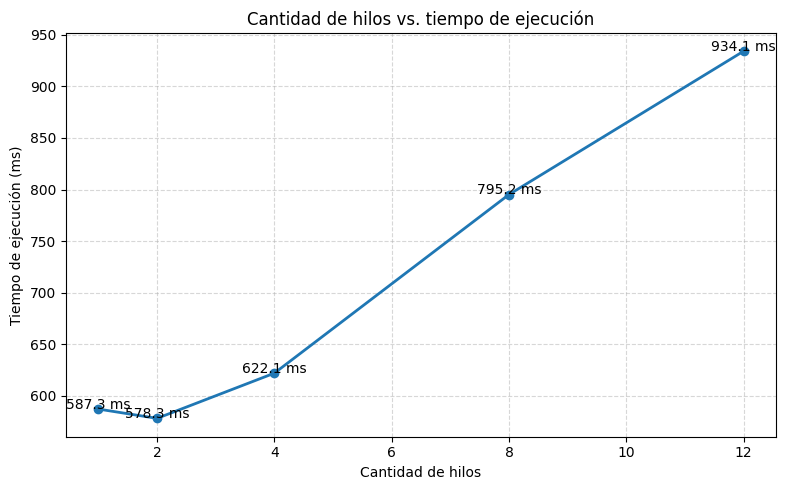

In [ ]:
import matplotlib.pyplot as plt

# Cantidad de hilos
threads_to_test = [1, 2, 4, 8, 12]

# Tiempo de ejecución para cada cantidad de hilos
times = [587.3, 578.3, 622.1, 795.2, 934.1]

plt.figure(figsize=(8, 5))

plt.plot(threads_to_test, times, marker="o", linewidth=2)

plt.xlabel("Cantidad de hilos")
plt.ylabel("Tiempo de ejecución (ms)")
plt.title("Cantidad de hilos vs. tiempo de ejecución")

# Mostrar los valores sobre cada punto
for x, y in zip(threads_to_test, times):
    plt.text(x, y + 0.1, f"{y:.1f} ms", ha='center')

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

##Conclusión: ¿Aumentar indefinidamente la cantidad de hilos mejora el rendimiento?
Luego de ejecutar varias veces el algoritmo, el menor tiempo de ejecución se obtuvo mayormente utilizando 1 hilo, con un tiempo aproximados de de 0.5 segundos.
A partir de los resultados obtenidos, se puede observar que aumentar la cantidad de hilos no produce una mejora indefinida en el rendimiento. Por el contrario, en este experimento el tiempo aumentó al utilizar una mayor cantidad de hilos. Esto se debe al costo adicional de crear y administrar los hilos por el procesador cuando es un ejercicio de cálculo puro sin operaciones que bloqueen a los hilos (además de las limitaciones del GIL de Python para tareas que requieren procesamiento de CPU).